In [1]:
pip install hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 18.1 MB/s eta 0:00:00


In [2]:
import os
print(os.getcwd())

/content


In [3]:
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

Cloning into 'free-spoken-digit-dataset'...
remote: Enumerating objects: 4260, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 4260 (delta 25), reused 8 (delta 8), pack-reused 4212 (from 1)
Receiving objects: 100% (4260/4260), 30.38 MiB | 14.13 MiB/s, done.
Resolving deltas: 100% (129/129), done.


# Short-Time Fourier Transform (STFT) Analysis

The Short-Time Fourier Transform (STFT) provides a time-frequency representation of a signal by dividing it into short segments and applying the Fourier transform to each segment. Unlike the conventional Fourier transform, which analyzes the entire signal at once and therefore loses time localization, the STFT makes it possible to observe how the frequency content changes with time. This is especially useful for speech signals, since they are non-stationary and their spectral content varies during pronunciation.

## Mathematical Definition

The STFT of a discrete-time signal $x[n]$ is defined as:

$$
X[m,k] = \sum_{n=-\infty}^{\infty} x[n] \, w[n-mH] \, e^{-j \frac{2\pi}{N}kn}
$$

where:

- $w[n]$ is the analysis window of length $L$
- $m$ is the window position index
- $H$ is the hop size between successive windows
- $k$ is the frequency-bin index
- $N$ is the FFT size used to compute the spectrum of each segment

The main idea is that each short segment is assumed to be approximately stationary, so its local spectrum can be meaningfully computed. By repeating this process across time, the STFT produces a spectrogram that shows the evolution of spectral energy over both time and frequency.

## Time-Frequency Resolution

A key limitation of the STFT is that it uses a fixed window for the entire signal, which means the time and frequency resolutions are also fixed. A narrow window gives better time resolution but poorer frequency resolution, while a wide window gives better frequency resolution but poorer time resolution. Therefore, selecting the window length is an important design choice in STFT-based analysis.

## Implementation in This Work

In this work, the STFT was implemented using a Hann window with:

- window length $L = 512$ samples
- FFT size $N = 512$
- hop length $H = 64$ samples

Two STFT-based feature extraction approaches were investigated.

### Approach 1: Statistical Summary of Frame-Wise Spectral Features

In the first approach, the magnitude spectrogram was computed for each recording and several short-time spectral descriptors were extracted frame by frame. The extracted features were:

- spectral centroid
- spectral bandwidth
- spectral rolloff
- spectral flatness
- RMS energy
- dominant frequency per frame
- band-energy ratios over the ranges 0--500 Hz, 500--1000 Hz, 1000--2000 Hz, and 2000--4000 Hz

Since each recording contains a different number of frames, every frame-wise feature sequence was converted into a fixed-length representation by computing six statistical measures:

- minimum
- maximum
- mean
- standard deviation
- skewness
- kurtosis

These statistical summaries were concatenated to form the final STFT feature vector for each spoken-digit recording.

### Approach 2: Spectrogram Block-Based Features

In the second approach, the normalized magnitude spectrogram was divided into fixed time-frequency blocks. Instead of summarizing only a few frame-wise spectral descriptors, this method preserved more of the actual spectrogram structure. For each block, two statistical measures were computed:

- block mean
- block standard deviation

These block statistics were concatenated to form the final feature vector. This approach was expected to better capture the distribution of energy across both time and frequency, and therefore preserve more discriminative information for spoken-digit classification.

## Classification Stage

For both approaches, the extracted STFT feature vectors were used as inputs to a Random Forest classifier for spoken-digit recognition. The results of the two approaches were then compared in terms of classification performance and feature representation capability.

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import ipywidgets as widgets
from IPython.display import display, clear_output

In [5]:
# 1) DATASET PATH
DATA_DIR = Path("/content/free-spoken-digit-dataset/recordings")
files = sorted(DATA_DIR.glob("*.wav"))
if len(files) == 0:
    raise FileNotFoundError(f"No .wav files found in: {DATA_DIR}")

In [6]:
def find_filename(file_path):
    """
    Example:
    7_george_13.wav

    Returns:
    digit   -> 7
    speaker -> george
    index   -> 13
    """
    parts = file_path.stem.split("_")
    digit = int(parts[0])
    speaker = parts[1]
    index = int(parts[2])
    return digit, speaker, index


def build_file_catalog(files):
    """
    Build a list of dictionaries containing file metadata.
    """
    catalog = []
    for f in files:
        digit, speaker, index = find_filename(f)
        catalog.append({
            "path": f,
            "digit": digit,
            "speaker": speaker,
            "index": index
        })
    return catalog


def get_speakers(catalog):
    return sorted({item["speaker"] for item in catalog})


def get_digits_for_speaker(catalog, speaker):
    return sorted({item["digit"] for item in catalog if item["speaker"] == speaker})


def get_indices_for_speaker_digit(catalog, speaker, digit):
    return sorted({
        item["index"]
        for item in catalog
        if item["speaker"] == speaker and item["digit"] == digit
    })


def get_file_by_selection(catalog, speaker, digit, index):
    """
    Return the selected file path based on speaker, digit, and index.
    """
    matches = [
        item["path"]
        for item in catalog
        if item["speaker"] == speaker
        and item["digit"] == digit
        and item["index"] == index
    ]

    if len(matches) == 0:
        return None

    return matches[0]


def load_audio(file_path):
    """
    Load one audio file.
    """
    y, sr = librosa.load(file_path, sr=None, mono=True)
    return y, sr


def plot_spectrum_and_spectrogram(
    file_path,
    n_fft=512,
    win_length=512,
    hop_length=64,
    window="hann"
):
    """
    Plot:
    1) Full-signal FFT spectrum
    2) Linear STFT spectrogram
    """
    if file_path is None:
        print("No matching file found.")
        return

    if win_length > n_fft:
        print("Error: WIN_LENGTH must be less than or equal to N_FFT.")
        return

    if hop_length <= 0:
        print("Error: HOP_LENGTH must be positive.")
        return

    try:
        y, sr = load_audio(file_path)
        # Full-signal FFT spectrum
        Y = np.fft.rfft(y)
        magnitude = np.abs(Y)
        freqs = np.fft.rfftfreq(len(y), d=1/sr)

        # Linear STFT spectrogram
        S = librosa.stft(
            y,
            n_fft=n_fft,
            win_length=win_length,
            hop_length=hop_length,
            window=window
        )
        S_mag = np.abs(S)

        # Plot
        fig, axes = plt.subplots(2, 1, figsize=(12, 10))

        # Top: FFT spectrum
        axes[0].plot(freqs, magnitude)
        axes[0].set_title(f"FFT Spectrum - {file_path.name}")
        axes[0].set_xlabel("Frequency (Hz)")
        axes[0].set_ylabel("Magnitude")
        axes[0].set_xlim(0, sr / 2)
        axes[0].grid(True)

        # Bottom: Linear spectrogram
        img = librosa.display.specshow(
            S_mag,
            sr=sr,
            hop_length=hop_length,
            x_axis="time",
            y_axis="hz",
            ax=axes[1]
        )
        axes[1].set_title(
            f"Linear Spectrogram - {file_path.name}\n"
            f"window={window}, n_fft={n_fft}, win_length={win_length}, hop_length={hop_length}"
        )
        fig.colorbar(img, ax=axes[1], label="Magnitude")

        plt.tight_layout()
        plt.show()

        # Extra info
        duration = len(y) / sr
        print(f"Selected file : {file_path.name}")
        print(f"Duration      : {duration:.4f} s")
        print(f"Sampling rate : {sr} Hz")
        print(f"N_FFT         : {n_fft}")
        print(f"WIN_LENGTH    : {win_length}")
        print(f"HOP_LENGTH    : {hop_length}")
        print(f"WINDOW        : {window}")
        print("Note: the window selection affects the STFT spectrogram.")
        print("The FFT spectrum here is the whole-signal FFT, same as your original code.")

    except Exception as e:
        print(f"Error while plotting: {e}")



# 3) BUILD CATALOG
catalog = build_file_catalog(files)


# 4) CREATE WIDGETS
speaker_dropdown = widgets.Dropdown(
    options=get_speakers(catalog),
    description="Speaker:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

digit_dropdown = widgets.Dropdown(
    options=[],
    description="Digit:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

index_dropdown = widgets.Dropdown(
    options=[],
    description="Index:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

window_dropdown = widgets.Dropdown(
    options=["boxcar", "hann", "hamming"],
    value="hann",
    description="Window:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

nfft_dropdown = widgets.Dropdown(
    options=[128, 256, 512, 1024],
    value=512,
    description="N_FFT:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

winlen_dropdown = widgets.Dropdown(
    options=[128, 256, 512, 1024],
    value=512,
    description="WIN_LENGTH:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

hop_dropdown = widgets.Dropdown(
    options=[32, 64, 128, 256],
    value=64,
    description="HOP_LENGTH:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="250px")
)

# !! This part of the code is done with created with assistance from Copilot !!
output_area = widgets.Output()

# 5) UPDATE FUNCTIONS
def update_digit_options(*args):
    speaker = speaker_dropdown.value
    digits = get_digits_for_speaker(catalog, speaker)
    digit_dropdown.options = digits
    if len(digits) > 0:
        digit_dropdown.value = digits[0]


def update_index_options(*args):
    speaker = speaker_dropdown.value
    digit = digit_dropdown.value
    indices = get_indices_for_speaker_digit(catalog, speaker, digit)
    index_dropdown.options = indices
    if len(indices) > 0:
        index_dropdown.value = indices[0]


def refresh_plot(*args):
    with output_area:
        clear_output(wait=True)

        speaker = speaker_dropdown.value
        digit = digit_dropdown.value
        index = index_dropdown.value
        window = window_dropdown.value
        n_fft = nfft_dropdown.value
        win_length = winlen_dropdown.value
        hop_length = hop_dropdown.value

        file_path = get_file_by_selection(catalog, speaker, digit, index)

        plot_spectrum_and_spectrogram(
            file_path=file_path,
            n_fft=n_fft,
            win_length=win_length,
            hop_length=hop_length,
            window=window
        )


# 6) CONNECT WIDGET EVENTS
speaker_dropdown.observe(update_digit_options, names="value")
speaker_dropdown.observe(update_index_options, names="value")

digit_dropdown.observe(update_index_options, names="value")

speaker_dropdown.observe(refresh_plot, names="value")
digit_dropdown.observe(refresh_plot, names="value")
index_dropdown.observe(refresh_plot, names="value")
window_dropdown.observe(refresh_plot, names="value")
nfft_dropdown.observe(refresh_plot, names="value")
winlen_dropdown.observe(refresh_plot, names="value")
hop_dropdown.observe(refresh_plot, names="value")

# 7) INITIALIZE
update_digit_options()
update_index_options()

# 8) DISPLAY UI
controls_row1 = widgets.HBox([speaker_dropdown, digit_dropdown, index_dropdown])
controls_row2 = widgets.HBox([window_dropdown, nfft_dropdown, winlen_dropdown, hop_dropdown])

ui = widgets.VBox([
    controls_row1,
    controls_row2,
    output_area
])

display(ui)

# Initial plot
refresh_plot()

Number of files found: 3000
First 5 files:
0_george_0.wav
0_george_1.wav
0_george_10.wav
0_george_11.wav
0_george_12.wav

Shapes:
X_train: (2700, 60)
y_train: (2700,)
X_test : (300, 60)
y_test : (300,)
Feature vector length: 60

STFT-BASED MODEL RESULTS
Test Accuracy: 0.9133333333333333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        30
           1       0.87      0.90      0.89        30
           2       0.88      0.93      0.90        30
           3       0.84      0.90      0.87        30
           4       1.00      1.00      1.00        30
           5       0.96      0.90      0.93        30
           6       0.90      0.87      0.88        30
           7       0.88      0.93      0.90        30
           8       0.93      0.90      0.92        30
           9       0.90      0.93      0.92        30

    accuracy                           0.91       300
   macro avg       0.92      0.91     

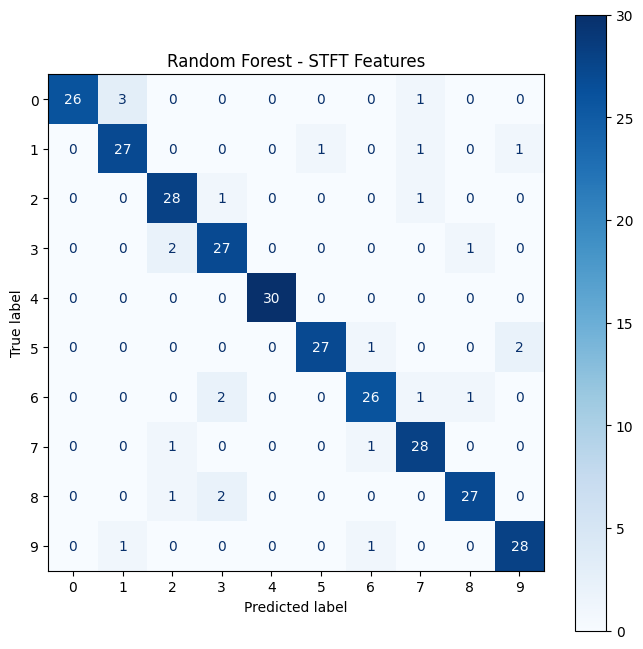


Feature Importance Ranking:
band500_1000_mean: 0.047219
rolloff_min: 0.046477
band500_1000_std: 0.037260
band1000_2000_min: 0.035220
band500_1000_max: 0.033649
rolloff_std: 0.031501
rolloff_mean: 0.030586
band500_1000_min: 0.029218
band0_500_mean: 0.027762
band2000_4000_min: 0.027734
bandwidth_min: 0.026167
rms_max: 0.025397
bandwidth_mean: 0.024134
band0_500_max: 0.023867
centroid_min: 0.023079
bandwidth_std: 0.021196
rms_std: 0.019706
centroid_mean: 0.018936
flatness_min: 0.016937
centroid_skew: 0.016687
band0_500_skew: 0.016658
rms_skew: 0.016443
domfreq_mean: 0.015712
domfreq_max: 0.014699
flatness_mean: 0.013970
band1000_2000_mean: 0.013626
centroid_max: 0.013470
domfreq_std: 0.013345
flatness_std: 0.013236
bandwidth_skew: 0.012929
rms_kurtosis: 0.012925
band500_1000_skew: 0.012689
centroid_std: 0.012299
bandwidth_max: 0.012214
band2000_4000_mean: 0.012181
band500_1000_kurtosis: 0.012164
band0_500_kurtosis: 0.012017
flatness_max: 0.011707
band1000_2000_std: 0.011609
band0_500_min

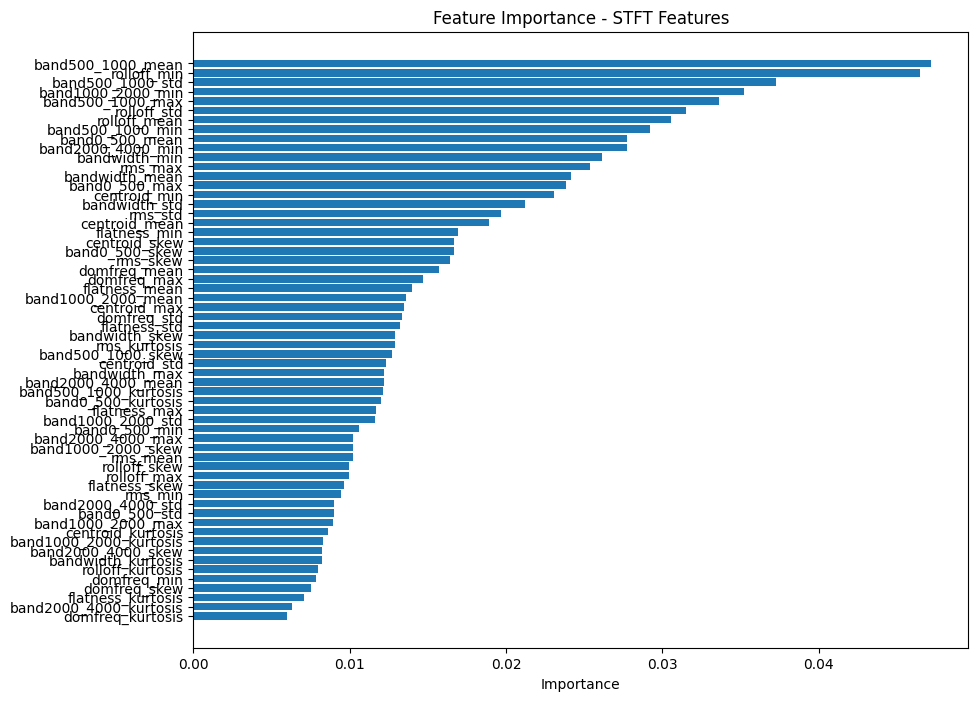

In [7]:
# STFT-BASED AUDIO CLASSIFICATION - Approach 1
RF_PARAMS = {
    "n_estimators": 400,
    "max_depth": 15,
    "min_samples_split": 4,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "random_state": 42
}

# !! Error Handling only is created with the help of Copilot !!

def find_filename(file_path: Path):
    """
    Parse filename of the form:
    digit_speaker_index.wav

    Example:
    0_jackson_32.wav -> (0, 'jackson', 32)
    """
    try:
        parts = file_path.stem.split("_")

        if len(parts) != 3:
            raise ValueError(
                f"Invalid filename format for '{file_path.name}'. "
                f"Expected digit_speaker_index.wav"
            )

        digit = int(parts[0])
        speaker = parts[1]
        index = int(parts[2])

        return digit, speaker, index

    except Exception as e:
        raise ValueError(f"Failed to get filename '{file_path.name}': {e}")

def get_wav_files(data_dir: Path):
    """
    Return sorted list of WAV files from the dataset directory.
    """
    if not data_dir.exists():
        raise FileNotFoundError(f"Dataset directory does not exist: {data_dir}")

    if not data_dir.is_dir():
        raise NotADirectoryError(f"Provided path is not a directory: {data_dir}")

    files = sorted(data_dir.glob("*.wav"))

    if len(files) == 0:
        raise FileNotFoundError(f"No .wav files found in: {data_dir}")

    return files

def load_audio(file_path: Path):
    """
    Load audio and normalize amplitude.
    Same logic as your original code.
    """
    try:
        y, sr = librosa.load(file_path, sr=None, mono=True)

        if y is None or len(y) == 0:
            raise ValueError("Loaded waveform is empty.")

        max_abs = np.max(np.abs(y))
        if max_abs > 0:
            y = y / max_abs

        return y, sr

    except Exception as e:
        raise RuntimeError(f"Failed to load audio '{file_path.name}': {e}")


# FEATURE EXTRACTION
def safe_stats(x):
    """
    Compute:
    min, max, mean, std, skewness, kurtosis

    Same logic as your original code.
    computed per frame feature
     """
    x = np.asarray(x, dtype=float)

    min_val = np.min(x)
    max_val = np.max(x)
    mean_val = np.mean(x)
    std_val = np.std(x)

    if np.allclose(std_val, 0):
        skew_val = 0.0
        kurt_val = 0.0
    else:
        skew_val = skew(x, bias=False)
        kurt_val = kurtosis(x, fisher=False, bias=False)

        if np.isnan(skew_val):
            skew_val = 0.0
        if np.isnan(kurt_val):
            kurt_val = 0.0

    return [min_val, max_val, mean_val, std_val, skew_val, kurt_val]


def extract_stft_features(
    file_path: Path,
    n_fft: int = 512,
    win_length: int = 512,
    hop_length: int = 64,
    window: str = "hann"
):
    """
    Extract the same STFT-based features (computed per frame)
    - centroid
    - bandwidth
    - rolloff
    - flatness
    - rms
    - dominant frequency
    - band-energy ratios
    Then summarize each with safe_stats().
    """
    try:
        y, sr = load_audio(file_path)
        """
         STFT (return complex matrix spectrum coefficient per frame
          (#N frames *spectrum coefficient )
        """

        S = librosa.stft(
            y,
            n_fft=n_fft,
            win_length=win_length,
            hop_length=hop_length,
            window=window
        )

        magnitude = np.abs(S)
        power = magnitude ** 2

        # Frame-wise STFT spectral features
        centroid = librosa.feature.spectral_centroid(S=magnitude, sr=sr)[0]
        bandwidth = librosa.feature.spectral_bandwidth(S=magnitude, sr=sr)[0]
        rolloff = librosa.feature.spectral_rolloff(
            S=magnitude,
            sr=sr,
            roll_percent=0.85
        )[0]
        flatness = librosa.feature.spectral_flatness(S=magnitude)[0]

        # RMS with matching frame length
        rms = librosa.feature.rms(S=magnitude, frame_length=n_fft)[0]

        # Dominant frequency per frame
        freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
        dominant_bin = np.argmax(magnitude, axis=0)
        dominant_freq = freqs[dominant_bin]

        # Band-energy ratios per frame
        total_power_per_frame = np.sum(power, axis=0) + 1e-12

        def band_ratio(f_low, f_high):
            idx = np.where((freqs >= f_low) & (freqs < f_high))[0]
            if len(idx) == 0:
                return np.zeros(power.shape[1])
            return np.sum(power[idx, :], axis=0) / total_power_per_frame

        band_0_500 = band_ratio(0, 500)
        band_500_1000 = band_ratio(500, 1000)
        band_1000_2000 = band_ratio(1000, 2000)
        band_2000_4000 = band_ratio(2000, 4000)

        # Statistical summaries
        features = (
            safe_stats(centroid)
            + safe_stats(bandwidth)
            + safe_stats(rolloff)
            + safe_stats(flatness)
            + safe_stats(rms)
            + safe_stats(dominant_freq)
            + safe_stats(band_0_500)
            + safe_stats(band_500_1000)
            + safe_stats(band_1000_2000)
            + safe_stats(band_2000_4000)
        )

        return np.array(features, dtype=float)

    except Exception as e:
        raise RuntimeError(f"Feature extraction failed for '{file_path.name}': {e}")


def get_feature_names():
    """
    Return the feature names in the same order as the feature vector.
    """
    return [
        "centroid_min", "centroid_max", "centroid_mean", "centroid_std", "centroid_skew", "centroid_kurtosis",
        "bandwidth_min", "bandwidth_max", "bandwidth_mean", "bandwidth_std", "bandwidth_skew", "bandwidth_kurtosis",
        "rolloff_min", "rolloff_max", "rolloff_mean", "rolloff_std", "rolloff_skew", "rolloff_kurtosis",
        "flatness_min", "flatness_max", "flatness_mean", "flatness_std", "flatness_skew", "flatness_kurtosis",
        "rms_min", "rms_max", "rms_mean", "rms_std", "rms_skew", "rms_kurtosis",
        "domfreq_min", "domfreq_max", "domfreq_mean", "domfreq_std", "domfreq_skew", "domfreq_kurtosis",
        "band0_500_min", "band0_500_max", "band0_500_mean", "band0_500_std", "band0_500_skew", "band0_500_kurtosis",
        "band500_1000_min", "band500_1000_max", "band500_1000_mean", "band500_1000_std", "band500_1000_skew", "band500_1000_kurtosis",
        "band1000_2000_min", "band1000_2000_max", "band1000_2000_mean", "band1000_2000_std", "band1000_2000_skew", "band1000_2000_kurtosis",
        "band2000_4000_min", "band2000_4000_max", "band2000_4000_mean", "band2000_4000_std", "band2000_4000_skew", "band2000_4000_kurtosis"
    ]



# DATASET PREPARATION
def build_train_test_sets(
    files,
    n_fft: int,
    win_length: int,
    hop_length: int,
    window: str
):
    """
    Build train/test sets using the same split rule:
    index 0-4 -> test (10%)
    index 5-49 -> train (90%)
    """
    X_train, y_train = [], []
    X_test, y_test = [], []

    for file_path in files:
        digit, speaker, index = find_filename(file_path)

        features = extract_stft_features(
            file_path=file_path,
            n_fft=n_fft,
            win_length=win_length,
            hop_length=hop_length,
            window=window
        )

        if index <= 4:
            X_test.append(features)
            y_test.append(digit)
        else:
            X_train.append(features)
            y_train.append(digit)

    if len(X_train) == 0 or len(X_test) == 0:
        raise RuntimeError("Training or testing set is empty after dataset processing.")

    return (
        np.array(X_train),
        np.array(y_train),
        np.array(X_test),
        np.array(y_test)
    )


# MODELING
def train_random_forest(X_train, y_train, rf_params: dict):
    """
    Train Random Forest using the same parameters as your original code.
    """
    try:
        model = RandomForestClassifier(**rf_params)
        model.fit(X_train, y_train)
        return model
    except Exception as e:
        raise RuntimeError(f"Model training failed: {e}")


def evaluate_model(model, X_test, y_test):
    """
    Evaluate model on test set.
    """
    try:
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        return y_pred, acc, report, cm
    except Exception as e:
        raise RuntimeError(f"Model evaluation failed: {e}")


# !! VISUALIZATION is created with the help of copilot !!

# VISUALIZATION
def plot_confusion_matrix(cm, title="Random Forest - STFT Features"):
    """
    Plot confusion matrix.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.arange(10)
    )
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    plt.title(title)
    plt.show()


def print_feature_importance(model, feature_names):
    """
    Print and plot feature importance ranking.
    """
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]

    print("\nFeature Importance Ranking:")
    for i in sorted_idx:
        print(f"{feature_names[i]}: {importances[i]:.6f}")

    plt.figure(figsize=(10, 8))
    plt.barh(
        [feature_names[i] for i in sorted_idx],
        [importances[i] for i in sorted_idx]
    )
    plt.gca().invert_yaxis()
    plt.xlabel("Importance")
    plt.title("Feature Importance - STFT Features")
    plt.show()


# REPORTING
def print_dataset_summary(files, X_train, y_train, X_test, y_test):
    """
    Print dataset summary and shapes.
    """
    print("Number of files found:", len(files))
    print("First 5 files:")
    for f in files[:5]:
        print(f.name)

    print("\nShapes:")
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test :", X_test.shape)
    print("y_test :", y_test.shape)
    print("Feature vector length:", X_train.shape[1])


def print_results(acc, report):
    """
    Print model results.
    """
    print("\n==============================")
    print("STFT-BASED MODEL RESULTS")
    print("==============================")
    print("Test Accuracy:", acc)
    print("\nClassification Report:")
    print(report)


# MAIN
def main():
    try:
        files = get_wav_files(DATA_DIR)

        X_train, y_train, X_test, y_test = build_train_test_sets(
            files=files,
            n_fft=512,
            win_length=512,
            hop_length=64,
            window='hann'
        )

        print_dataset_summary(files, X_train, y_train, X_test, y_test)

        model = train_random_forest(
            X_train=X_train,
            y_train=y_train,
            rf_params=RF_PARAMS
        )

        y_pred, acc, report, cm = evaluate_model(
            model=model,
            X_test=X_test,
            y_test=y_test
        )

        print_results(acc, report)

        plot_confusion_matrix(cm)
        print_feature_importance(model, get_feature_names())

    except Exception as e:
        print(f"\nFatal error: {e}")


if __name__ == "__main__":
    main()

Number of files found: 3000
First 5 files:
0_george_0.wav
0_george_1.wav
0_george_10.wav
0_george_11.wav
0_george_12.wav

Shapes:
X_train: (2700, 160)
y_train: (2700,)
X_test : (300, 160)
y_test : (300,)
Feature vector length: 160

STFT BLOCK-FEATURE MODEL RESULTS
Test Accuracy: 0.9566666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        30
           1       0.97      1.00      0.98        30
           2       0.90      0.93      0.92        30
           3       0.85      0.97      0.91        30
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00        30
           6       0.90      0.93      0.92        30
           7       1.00      0.97      0.98        30
           8       1.00      0.90      0.95        30
           9       1.00      0.97      0.98        30

    accuracy                           0.96       300
   macro avg       0.96    

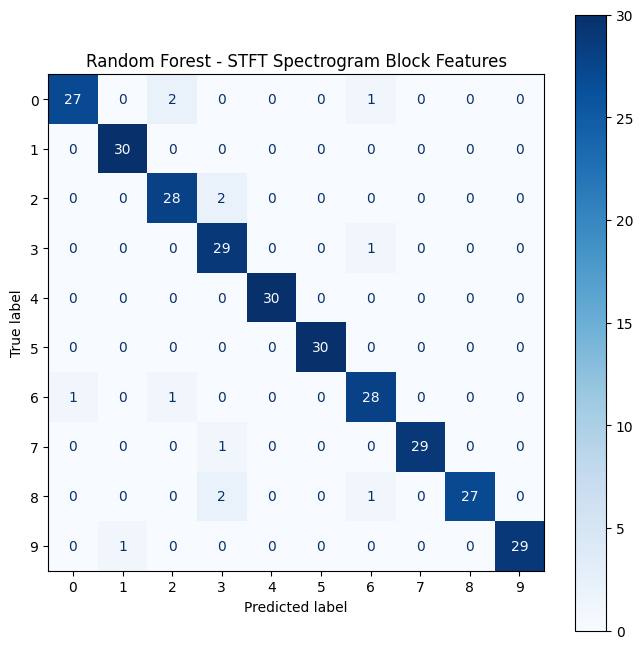


Top 20 Feature Importances:
F2_T3_std: 0.017227
F2_T2_std: 0.015239
F3_T3_mean: 0.014679
F3_T4_mean: 0.014544
F1_T1_mean: 0.013712
F2_T4_mean: 0.013559
F3_T1_std: 0.013417
F2_T4_std: 0.013306
F2_T3_mean: 0.012461
F3_T2_std: 0.012408
F3_T2_mean: 0.012385
F3_T3_std: 0.012364
F3_T4_std: 0.012126
F5_T1_std: 0.011796
F2_T2_mean: 0.011763
F3_T1_mean: 0.011629
F2_T5_mean: 0.010930
F0_T3_std: 0.010714
F1_T7_mean: 0.010467
F5_T1_mean: 0.010422


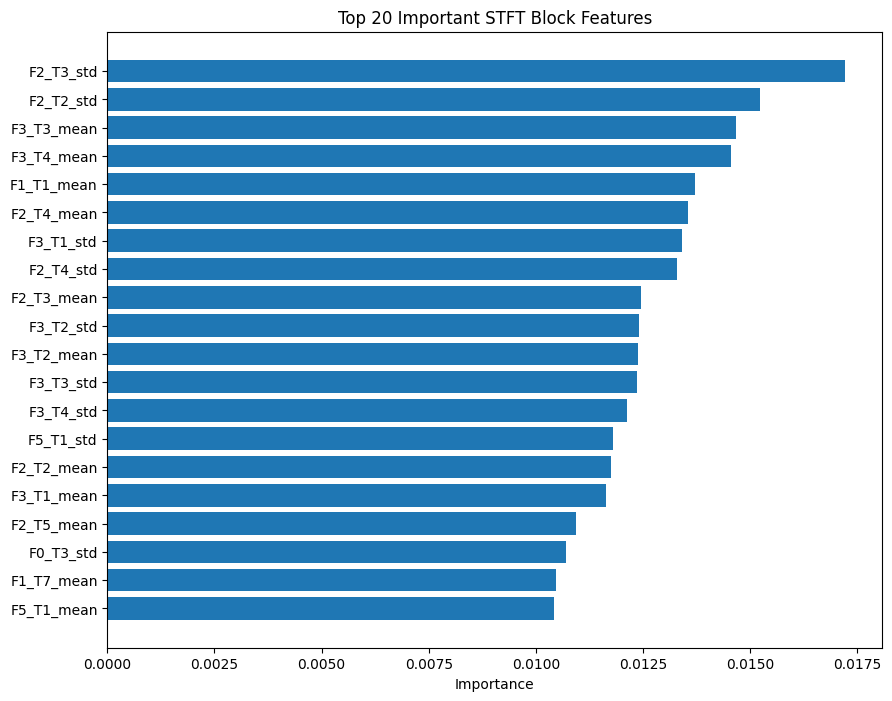

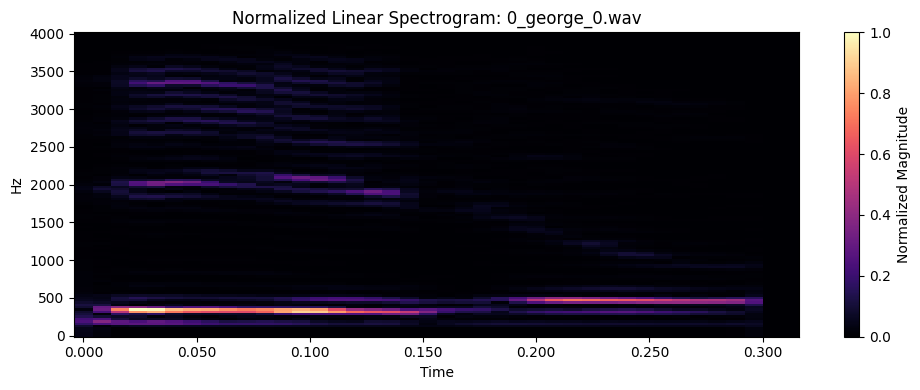

In [8]:
# STFT SPECTROGRAM-BLOCK FEATURES + RANDOM FOREST

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 1) DATASET PATH
DATA_DIR = Path("/content/free-spoken-digit-dataset/recordings")
files = sorted(DATA_DIR.glob("*.wav"))

print("Number of files found:", len(files))
print("First 5 files:")
for f in files[:5]:
    print(f.name)

# 2) STFT PARAMETERS
N_FFT = 256
WIN_LENGTH = 256
HOP_LENGTH = 64
WINDOW = "hann"
# 3) BLOCK PARAMETERS
# Number of blocks along frequency and time
N_FREQ_BLOCKS = 10
N_TIME_BLOCKS = 8

# Force every spectrogram to have the same number of time frames
FIXED_TIME_FRAMES = 40

# 4) HELPER FUNCTIONS
def parse_filename(file_path):
    """
    Example:
    0_jackson_32.wav

    Returns:
    digit   -> 0
    speaker -> jackson
    index   -> 32
    """
    parts = file_path.stem.split("_")
    digit = int(parts[0])
    speaker = parts[1]
    index = int(parts[2])
    return digit, speaker, index


def load_audio(file_path):
    """
    Load audio and normalize waveform amplitude.
    """
    y, sr = librosa.load(file_path, sr=None, mono=True)

    max_abs = np.max(np.abs(y))
    if max_abs > 0:
        y = y / max_abs

    return y, sr


def extract_block_spectrogram_features(
    file_path,
    n_fft=256,
    win_length=256,
    hop_length=64,
    window="hann",
    n_freq_blocks=8,
    n_time_blocks=8,
    fixed_time_frames=32
):
    """
    Extract STFT spectrogram-block features.

    Steps:
    1) Compute STFT
    2) Take magnitude spectrogram
    3) Normalize spectrogram by its maximum
    4) Force all files to have the same number of time frames
    5) Split into time-frequency blocks
    6) For each block, compute mean and std

    Returns:
    1D numpy array of features
    """
    y, sr = load_audio(file_path)

    # -------------------------
    # STFT
    # -------------------------
    S = librosa.stft(
        y,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        window=window
    )

    # Magnitude spectrogram
    spec = np.abs(S)

    # Normalize so loud/quiet recordings are more comparable
    spec = spec / (np.max(spec) + 1e-12)

    # Make all spectrograms have the same number of time frames
    # If shorter -> zero-pad
    # If longer  -> truncate
    spec = librosa.util.fix_length(spec, size=fixed_time_frames, axis=1)

    # Frequency bins are already fixed because n_fft is fixed
    n_freq_bins, n_time_frames = spec.shape

    # Split rows and columns into blocks
    freq_indices = np.array_split(np.arange(n_freq_bins), n_freq_blocks)
    time_indices = np.array_split(np.arange(n_time_frames), n_time_blocks)

    features = []

    # For each time-frequency block, compute mean and std
    for f_idx in freq_indices:
        for t_idx in time_indices:
            block = spec[np.ix_(f_idx, t_idx)]

            block_mean = np.mean(block)
            block_std = np.std(block)

            features.extend([block_mean, block_std])

    return np.array(features, dtype=float)


# 5) FEATURE NAMES
feature_names = []
for fb in range(N_FREQ_BLOCKS):
    for tb in range(N_TIME_BLOCKS):
        feature_names.append(f"F{fb}_T{tb}_mean")
        feature_names.append(f"F{fb}_T{tb}_std")

# 6) BUILD TRAIN / TEST SETS
# index 0-4 -> test
# index 5-49 -> train
X_train = []
y_train = []

X_test = []
y_test = []

for f in files:
    digit, speaker, index = parse_filename(f)

    features = extract_block_spectrogram_features(
        f,
        n_fft=N_FFT,
        win_length=WIN_LENGTH,
        hop_length=HOP_LENGTH,
        window=WINDOW,
        n_freq_blocks=N_FREQ_BLOCKS,
        n_time_blocks=N_TIME_BLOCKS,
        fixed_time_frames=FIXED_TIME_FRAMES
    )

    if index <= 4:
        X_test.append(features)
        y_test.append(digit)
    else:
        X_train.append(features)
        y_train.append(digit)

X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("Feature vector length:", X_train.shape[1])

# 7) TRAIN RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42
)

rf.fit(X_train, y_train)

# 8) TEST MODEL
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("\n==============================")
print("STFT BLOCK-FEATURE MODEL RESULTS")
print("==============================")
print("Test Accuracy:", acc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# 9) CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Random Forest - STFT Spectrogram Block Features")
plt.show()

# 10) FEATURE IMPORTANCE
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("\nTop 20 Feature Importances:")
for i in sorted_idx[:20]:
    print(f"{feature_names[i]}: {importances[i]:.6f}")

plt.figure(figsize=(10, 8))
top_k = 20
top_idx = sorted_idx[:top_k]

plt.barh(
    [feature_names[i] for i in top_idx][::-1],
    [importances[i] for i in top_idx][::-1]
)
plt.xlabel("Importance")
plt.title("Top 20 Important STFT Block Features")
plt.show()


# !! VISUALIZATION is created with the help of copilot !!

# 11) VISUALIZE ONE SPECTROGRAM USED BY THE MODEL
example_file = files[0]
y, sr = load_audio(example_file)

S = librosa.stft(
    y,
    n_fft=N_FFT,
    win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH,
    window=WINDOW
)

spec = np.abs(S)
spec = spec / (np.max(spec) + 1e-12)
spec = librosa.util.fix_length(spec, size=FIXED_TIME_FRAMES, axis=1)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    spec,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(label="Normalized Magnitude")
plt.title(f"Normalized Linear Spectrogram: {example_file.name}")
plt.tight_layout()
plt.show()